In [ ]:
!pip install tensorflow

In [2]:
import tensorflow as tf
tf.__version__

I0000 00:00:1780622877.725179  114402 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780622878.246015  114402 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780622879.775597  114402 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


'2.21.0'

---

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [2]:
data = pd.read_csv("Iris.csv", index_col="Id")
data.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
X = data.drop("Species", axis=1).to_numpy()
y = data[["Species"]].to_numpy()

In [4]:
scaler = StandardScaler()
onehot = OneHotEncoder(sparse_output=False)

scaled_X = scaler.fit_transform(X)
enc_y = onehot.fit_transform(y)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    scaled_X, enc_y, test_size=0.2, shuffle=True, stratify=enc_y, random_state=899
)

## Model Creation and Compile

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.initializers import RandomNormal

I0000 00:00:1780625458.612143  127266 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780625458.649517  127266 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780625459.497619  127266 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [7]:
inp_shape = X_test.shape[1]
num_classes = y_train.shape[1]

In [8]:
initialize = RandomNormal()

In [ ]:
model = Sequential()

model.add(Input(shape= (inp_shape, ))) #<- Input Layer

model.add(Dense(32, activation="relu")) #- Hidden Layer
model.add(Dense(16, activation="tanh")) #- Hidden Layer

model.add(Dense(num_classes, activation="softmax")) #<- Output layer


model.compile(
    optimizer = "Adam", loss = "categorical_crossentropy", metrics = ["accuracy"]
)

```Input shape (4 features ) + 1 bias -> 5 x 16 -> 80 weights```

```Same for other layers, except for output layer```

In [45]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739 (2.89 KB)

 Trainable params: 739 (2.89 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
history = model.fit(
    X_train, y_train, epochs = 50, batch_size = 32
)

Epoch 1/50


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3917 - loss: 1.2031  
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5083 - loss: 1.1053 
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5583 - loss: 1.0226 
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5833 - loss: 0.9484 
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5667 - loss: 0.8815 
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6250 - loss: 0.8234 
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6833 - loss: 0.7738 
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7417 - loss: 0.7275 
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7750 - loss: 0.6861 
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7750 - loss: 0.6500 
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7833 - loss: 0.6166 
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7833 - loss: 0.5874 
Epoch 13/50

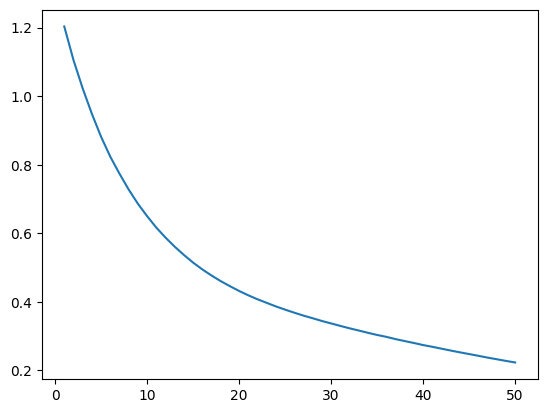

In [47]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
loss = history.history['loss']

# plt.plot(range(1,51), acc)
plt.plot(range(1,51), loss)

In [48]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,219 (8.67 KB)

 Trainable params: 739 (2.89 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,480 (5.79 KB)

In [19]:
loss, acc = model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8333 - loss: 0.5054


In [21]:
acc

0.8333333134651184

In [24]:
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [27]:
y_pred, y_true

(array([1, 2, 0, 2, 0, 0, 2, 2, 2, 0, 0, 2, 0, 0, 0, 2, 1, 2, 2, 1, 2, 1,
        1, 0, 0, 2, 1, 2, 1, 2]),
 array([1, 2, 0, 2, 0, 0, 2, 2, 2, 0, 0, 1, 0, 0, 0, 2, 1, 2, 2, 1, 1, 1,
        1, 0, 0, 1, 1, 1, 2, 2]))

In [28]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, auc

In [29]:
confusion_matrix(y_true, y_pred)

array([[10,  0,  0],
       [ 0,  6,  4],
       [ 0,  1,  9]])

In [30]:
onehot.categories_

[array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)]

In [32]:
f1_score(y_true, y_pred, average = "micro")

0.8333333333333334

In [49]:
model.save("iris_classifier.keras")

In [50]:
import pickle

In [51]:
to_package = {
    "scaler" : scaler,
    "encoder" : onehot,
    "model" : model
}

with open("iris_classifier.pkl", "wb") as file:
    pickle.dump(to_package, file)